<a href="https://colab.research.google.com/github/otavioolimpio/lego-cv-checker/blob/main/Lego_CV_Checker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Visão Computacional para Validação de Kits LEGO

Este projeto implementa um sistema de visão computacional desenvolvido em Python para automatizar a contagem e validação de peças LEGO. O algoritmo processa cenários complexos contendo múltiplos componentes dispersos simultaneamente na mesa, realizando uma auditoria automática de inventário com base em um manual calibrado de acordo com as condições reais da bancada de ensaios.

## Etapas do Processo:

1. **Configuração do Inventário Gabarito e Interface de Seleção**: Define o banco de dados das peças LEGO com suas respectivas regras morfológicas e quantidades esperadas, permitindo ao usuário selecionar o modelo-alvo por meio de um formulário interativo.
2. **Carregamento da Imagem e Segmentação por Cor (Espaço HSI)**: Converte a imagem capturada para o espaço de cores **HSI** (Matiz, Saturação e Intensidade) de forma a isolar com precisão o canal cromático (Matiz) da peça-alvo, mitigando variações causadas por sombras e reflexos.
3. **Morfologia Matemática (Tratamento de Ruídos e Falhas)**: Aplica operações algébricas compostas de Fechamento (`cv2.MORPH_CLOSE`), para unificar contornos e tapar os furos internos característicos de vigas Technic, seguido por uma Abertura (`cv2.MORPH_OPEN`) para eliminar ruídos espaciais e poeiras de fundo na máscara binária.
4. **Extração de Contornos e Classificação por Descritores Geométricos Invariantes**: Extrai as curvas de borda e ajusta retângulos rotacionados de área mínima (`cv2.minAreaRect`). O sistema calcula descritores geométricos intrínsecos — como **Razão de Aspecto** (*Aspect Ratio* verdadeiro) e **Fator de Compactação** (*Extent*) — e aplica um filtro de dominância para isolar estritamente o maior candidato válido, descartando falsos positivos.
5. **Validação do Kit e Exibição do Resultado Visual Final**: Efetua a auditoria comparando o total físico computado com a meta do manual. O programa desenha os contornos rotacionados exatos ao redor do objeto validado, insere rótulos descritivos no seu baricentro geométrico e apresenta na tela um relatório textual junto ao veredito final do Kit.

In [11]:
# ==============================================================================
# ETAPA 1: CONFIGURAÇÃO DO INVENTÁRIO (GABARITO REAL) E INTERFACE DE SELEÇÃO
# ==============================================================================
# [TÓPICO PDI: RECONHECIMENTO DE PADRÕES E CLASSIFICAÇÃO]
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

# Dicionário reconfigurado combinando o formato do manual com as cores da foto real
gabarito_kit_lego = {
    # --- PEÇAS VERMELHAS ---
    "cross_axle_2m_red":       {"cor": "vermelho", "proporcao_min": 3.0, "area_min": 150,  "qtd_esperada": 8},
    "brick_2x4_red":           {"cor": "vermelho", "proporcao_min": 1.5, "area_min": 1500, "qtd_esperada": 2},

    # --- PEÇAS VERDES ---
    "wire_clip_cross_green":   {"cor": "verde",    "proporcao_min": 1.0, "area_min": 150,  "qtd_esperada": 2},
    "brick_2x4_green":         {"cor": "verde",    "proporcao_min": 1.5, "area_min": 1500, "qtd_esperada": 2},

    # --- PEÇAS MAGENTAS / ROXAS ---
    "wire_clip_cross_magenta": {"cor": "magenta",  "proporcao_min": 1.0, "area_min": 150,  "qtd_esperada": 2},
    "technic_5m_beam_magenta": {"cor": "magenta",  "proporcao_min": 3.0, "area_min": 1000, "qtd_esperada": 4},
    "biscuit_1x3x3_magenta":   {"cor": "magenta",  "proporcao_min": 1.0, "area_min": 3500, "qtd_esperada": 6},

    # --- PEÇAS AZUIS / CIANO (Vigas reais observadas na foto) ---
    "technic_5m_beam_blue":    {"cor": "azul",     "proporcao_min": 3.0, "area_min": 1000, "qtd_esperada": 0}, # Modificada/Adaptada na bancada
    "technic_11m_beam_blue":   {"cor": "azul",     "proporcao_min": 5.0, "area_min": 2000, "qtd_esperada": 4}
}

#@markdown ### Selecione o modelo de peça Lego que deseja conferir na imagem:
peca_selecionada = "brick_2x4_red" #@param ["cross_axle_2m_red", "brick_2x4_red", "wire_clip_cross_green", "brick_2x4_green", "wire_clip_cross_magenta", "technic_5m_beam_magenta", "biscuit_1x3x3_magenta", "technic_5m_beam_blue", "technic_11m_beam_blue"]

# O programa busca os parâmetros do dicionário para alimentar o pipeline de PDI
dados_alvo = gabarito_kit_lego[peca_selecionada]
cor_alvo = dados_alvo["cor"]
quantidade_alvo = dados_alvo["qtd_esperada"]

# Exibição limpa e formatada confirmando a configuração do Alvo
print("=" * 65)
print(f"CONFIGURAÇÃO DO ALVO RECONFIGURADA COM SUCESSO:")
print(f"Peça selecionada: {peca_selecionada}")
print(f"Cor mapeada para rastreamento: {cor_alvo.upper()}")
print(f"Quantidade exigida no kit (Manual): {quantidade_alvo} unidades")
print("=" * 65)

CONFIGURAÇÃO DO ALVO RECONFIGURADA COM SUCESSO:
Peça selecionada: brick_2x4_red
Cor mapeada para rastreamento: VERMELHO
Quantidade exigida no kit (Manual): 2 unidades


Clique no botão abaixo para submeter a imagem:


Saving WhatsApp Image 2026-06-19 at 17.15.41 (2).jpeg to WhatsApp Image 2026-06-19 at 17.15.41 (2).jpeg


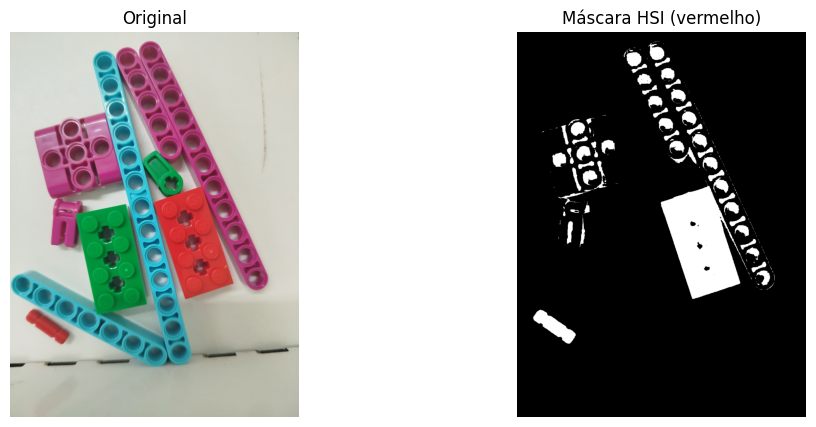

In [12]:
# ==============================================================================
# ETAPA 2: CARREGAMENTO DA IMAGEM E SEGMENTAÇÃO POR COR (ESPAÇO HSI)
# ==============================================================================
# [TÓPICO PDI: PROCESSAMENTO DE IMAGENS EM CORES & SEGMENTAÇÃO POR LIMIARIZAÇÃO]
# Esta célula faz a transformação não-linear do espaço de cores BGR para HSI
# baseado em equações geométricas e isola o canal cromático.
# ==============================================================================

from google.colab import files
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def bgr_para_hsi(img_bgr):
    """
    [CONCEITO TEÓRICO: TRASFORMAÇÃO CROMÁTICA MATEMÁTICA]
    Função dedicada a converter a imagem BGR nativa para o formato HSI de forma explícita.
    """
    img_normalizada = img_bgr.astype(np.float32) / 255.0
    B, G, R = img_normalizada[:,:,0], img_normalizada[:,:,1], img_normalizada[:,:,2]

    # Cálculo do Componente Intensidade (Média dos três canais)
    I = (R + G + B) / 3.0

    # Cálculo do Componente Saturação (Pureza da cor relativo à intensidade)
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = np.zeros_like(I)
    mascara_nao_preto = I > 0
    S[mascara_nao_preto] = 1.0 - (min_rgb[mascara_nao_preto] / I[mascara_nao_preto])

    # Cálculo do Componente Matiz (Hue) baseado no vetor angular do cosseno
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B))
    den[den == 0] = 1e-5 # Tratamento de descontinuidade / Divisão por zero

    theta = np.arccos(np.clip(num / den, -1.0, 1.0))
    H = np.degrees(theta)

    # Ajuste do mapeamento circular (Se B > G, o ângulo está no semicírculo inferior)
    H[B > G] = 360.0 - H[B > G]

    # Normalização dos valores para o tipo uint8 standard do OpenCV (H vai de 0 a 180)
    return cv2.merge([(H / 2).astype(np.uint8), (S * 255).astype(np.uint8), (I * 255).astype(np.uint8)])

print("Clique no botão abaixo para submeter a imagem:")
uploaded = files.upload()

if not uploaded:
    print("Erro: Nenhum arquivo submetido.")
else:
    nome_arquivo = list(uploaded.keys())[0]
    img_original = cv2.imread(nome_arquivo)

    # Aplicação da nossa função de conversão customizada
    img_hsi = bgr_para_hsi(img_original)

    # [TÓPICO PDI: DEFINIÇÃO DE LIMITES EM MODELOS DE COR]
    limites_hsi = {
        "vermelho": {
            "inf_1": np.array([0, 60, 40]), "sup_1": np.array([10, 255, 255]),
            "inf_2": np.array([168, 60, 40]), "sup_2": np.array([180, 255, 255])
        },
        "verde":   {"inf": np.array([35, 60, 40]), "sup": np.array([85, 255, 255])},
        "magenta": {"inf": np.array([135, 60, 40]), "sup": np.array([165, 255, 255])},
        "azul":    {"inf": np.array([90, 60, 40]), "sup": np.array([125, 255, 255])}
    }

    # [TÓPICO PDI: SEGMENTAÇÃO POR FATIAMENTO DE CANAL CROMÁTICO]
    # O comando cv2.inRange aplica uma binarização baseada em limiarização dupla (Multilevel Thresholding)
    if cor_alvo == "vermelho":
        mascara_cor = cv2.bitwise_or(
            cv2.inRange(img_hsi, limites_hsi["vermelho"]["inf_1"], limites_hsi["vermelho"]["sup_1"]),
            cv2.inRange(img_hsi, limites_hsi["vermelho"]["inf_2"], limites_hsi["vermelho"]["sup_2"])
        )
    else:
        mascara_cor = cv2.inRange(img_hsi, limites_hsi[cor_alvo]["inf"], limites_hsi[cor_alvo]["sup"])

    # Exibição dos resultados parciais da segmentação
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(mascara_cor, cmap='gray'); plt.title(f"Máscara HSI ({cor_alvo})"); plt.axis('off')
    plt.show()

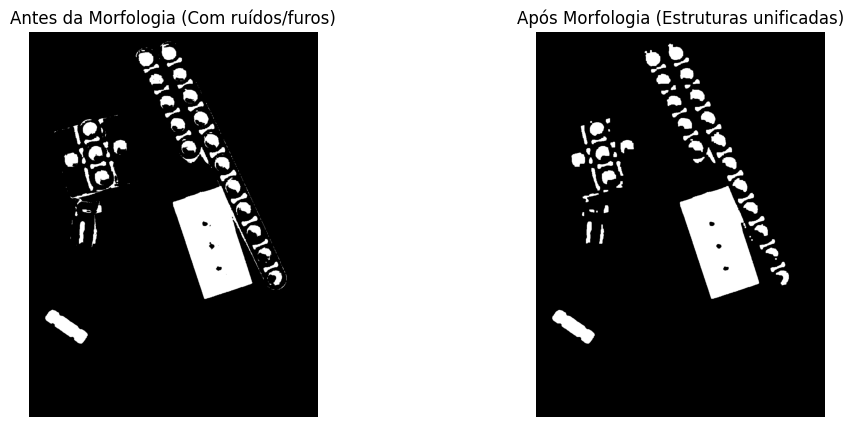

Etapa de Morfologia Matemática concluída usando kernel 5x5.


In [13]:
# ==============================================================================
# ETAPA 3: MORFOLOGIA MATEMÁTICA (TRATAMENTO DE RUÍDOS E FALHAS)
# ==============================================================================
# [TÓPICO PDI: MORFOLOGIA MATEMÁTICA E OPERADORES LOCAIS]
# Esta célula aplica operações morfológicas algébricas combinadas para corrigir
# a topologia das máscaras binárias obtidas na etapa de segmentação.
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# [CONCEITO TEÓRICO: ELEMENTO ESTRUTURANTE]
# O tamanho do kernel (elemento estruturante) define a escala dos detalhes que serão
# removidos ou preservados. Para furos de peças Technic, um tamanho entre 5 e 7 é ideal.
# Usamos MORPH_RECT, mas MORPH_ELLIPSE também funciona muito bem para estruturas circulares.
tamanho_kernel = 5
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (tamanho_kernel, tamanho_kernel))

# [TÓPICO PDI: FECHAMENTO MORFOLÓGICO (CLOSING)]
# O Fechamento é uma dilatação seguida por uma erosão ($A \bullet B = (A \oplus B) \ominus B$).
# Ele é altamente eficiente para preencher regiões escuras cercadas por estruturas claras,
# conectando contornos próximos e eliminando os furos internos característicos das vigas LEGO.
img_fechamento = cv2.morphologyEx(mascara_cor, cv2.MORPH_CLOSE, kernel)

# [TÓPICO PDI: ABERTURA MORFOLÓGICA (OPENING)]
# A Abertura é uma erosão seguida por uma dilatação ($A \circ B = (A \ominus B) \oplus B$).
# Ela funciona como um filtro de tamanho geométrico que remove componentes conectados brancos
# menores que o elemento estruturante (como poeira, pequenos reflexos ou ruídos da textura da mesa).
img_morfologia_limpa = cv2.morphologyEx(img_fechamento, cv2.MORPH_OPEN, kernel)

# [TÓPICO PDI: ANÁLISE DE RESULTADOS NO DOMÍNIO ESPACIAL]
# Exibição comparativa para validar o ganho de SNR (Relação Sinal-Ruído) da máscara binária.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mascara_cor, cmap='gray')
plt.title("Antes da Morfologia (Com ruídos/furos)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_morfologia_limpa, cmap='gray')
plt.title("Após Morfologia (Estruturas unificadas)")
plt.axis('off')

plt.show()

print(f"Etapa de Morfologia Matemática concluída usando kernel {tamanho_kernel}x{tamanho_kernel}.")

In [14]:
# ==============================================================================
# ETAPA 4: EXTRAÇÃO DE CONTORNOS E FILTRAGEM GEOMÉTRICA CALIBRADA (APENAS O MAIOR)
# ==============================================================================
# [TÓPICO PDI: DESCRIÇÃO E REPRESENTAÇÃO DE IMAGENS / DETECÇÃO DE OBJETOS]
# Esta célula extrai os vetores de borda e filtra o objeto com a maior assinatura
# geométrica válida, eliminando fragmentos menores ou ruídos remanescentes.
# ==============================================================================

import cv2
import numpy as np

# [TÓPICO PDI: DETECÇÃO DE OBJETOS E EXTRAÇÃO DE CONTORNOS]
contornos, _ = cv2.findContours(img_morfologia_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filtro preliminar de ruído por área absoluta mínima
contornos_filtrados_previamente = [cnt for cnt in contornos if cv2.contourArea(cnt) >= 150]

# Criamos uma lista para armazenar os candidatos válidos junto com suas respectivas áreas
candidatos_validos = []

print(f"\n[Análise Espacial] Iniciando extração de descritores para a cor {cor_alvo.upper()}:")
print("-" * 75)

for i, cnt in enumerate(contornos_filtrados_previamente):
    # [TÓPICO PDI: DESCRIÇÃO DE IMAGENS - PROPRIEDADES GEOMÉTRICAS ELEMENTARES]
    area = cv2.contourArea(cnt)

    # [TÓPICO PDI: TRANSFORMAÇÕES GEOMÉTRICAS / RETÂNGULO DE ÁREA MÍNIMA]
    rect = cv2.minAreaRect(cnt)
    (cx, cy), (w, h), angle = rect

    lado_maior = max(w, h)
    lado_menor = min(w, h) if min(w, h) > 0 else 1

    # Descritores geométricos invariantes
    aspect_ratio = lado_maior / lado_menor
    extent = area / (lado_maior * lado_menor)

    # [TÓPICO PDI: RECONHECIMENTO DE PADRÕES E CLASSIFICAÇÃO HEURÍSTICA]
    aceito = False

    if "brick_2x4" in peca_selecionada:
        if 1.4 <= aspect_ratio <= 2.4 and extent > 0.70:
            aceito = True
    elif "cross_axle_2m" in peca_selecionada:
        if aspect_ratio < 2.5 and area < 800:
            aceito = True
    elif "wire_clip_cross" in peca_selecionada:
        if aspect_ratio < 1.5 and area < 1000:
            aceito = True
    elif "technic_5m_beam" in peca_selecionada:
        if 2.5 <= aspect_ratio <= 4.5 and extent < 0.75:
            aceito = True
    elif "technic_11m_beam" in peca_selecionada or "technic_beam_blue" in peca_selecionada:
        if aspect_ratio > 4.5:
            aceito = True
    elif "biscuit" in peca_selecionada:
        if aspect_ratio < 1.8 and extent < 0.65:
            aceito = True

    if aceito:
        # Se passar no critério, guardamos o contorno e o tamanho dele para desempatar no final
        candidatos_validos.append((cnt, area, aspect_ratio, extent))
        print(f"Objeto [{i+1}]: Área = {int(area)} px | Candidato pré-aprovado.")
    else:
        print(f"Objeto [{i+1}]: Área = {int(area)} px | REJEITADO (Geometria incompatível).")

print("-" * 75)

# --- CRITÉRIO DE DESEMPATE CRÍTICO ---
contornos_validos = []
contagem_pecas = 0

if len(candidatos_validos) > 0:
    # Ordena os candidatos baseando-se na área (do maior para o menor)
    candidatos_ordenados = sorted(candidatos_validos, key=lambda x: x[1], reverse=True)

    # Selecionamos estritamente o MAIOR contorno que obedeceu às regras geométricas
    maior_candidato = candidatos_ordenados[0]
    cnt_final, area_final, ar_final, ext_final = maior_candidato

    contornos_validos.append(cnt_final)
    contagem_pecas = 1

    print(f"[RESULTADO]: Apenas o maior objeto válido foi selecionado:")
    print(f"   -> Peça: '{peca_selecionada}'")
    print(f"   -> Área Escolhida: {int(area_final)} px (Aspect Ratio: {ar_final:.2f} | Extent: {ext_final:.2f})")
else:
    print("Nenhuma peça correspondente ao padrão selecionado foi encontrada.")

print("-" * 75)


[Análise Espacial] Iniciando extração de descritores para a cor VERMELHO:
---------------------------------------------------------------------------
Objeto [1]: Área = 6159 px | REJEITADO (Geometria incompatível).
Objeto [2]: Área = 1053 px | REJEITADO (Geometria incompatível).
Objeto [3]: Área = 530 px | REJEITADO (Geometria incompatível).
Objeto [4]: Área = 736 px | REJEITADO (Geometria incompatível).
Objeto [5]: Área = 494 px | REJEITADO (Geometria incompatível).
Objeto [6]: Área = 517 px | REJEITADO (Geometria incompatível).
Objeto [7]: Área = 941 px | REJEITADO (Geometria incompatível).
Objeto [8]: Área = 916 px | REJEITADO (Geometria incompatível).
Objeto [9]: Área = 610 px | REJEITADO (Geometria incompatível).
Objeto [10]: Área = 303 px | Candidato pré-aprovado.
Objeto [11]: Área = 1135 px | Candidato pré-aprovado.
Objeto [12]: Área = 409 px | REJEITADO (Geometria incompatível).
Objeto [13]: Área = 631 px | REJEITADO (Geometria incompatível).
Objeto [14]: Área = 58290 px | Can

             RELATÓRIO DE CONFERÊNCIA DO KIT LEGO             
 Peça analisada: brick_2x4_red
 Quantidade na mesa: 1 unidade(s) | Manual pede: 2 unidade(s)
-----------------------------------------------------------------
KIT INCOMPLETO! Faltam 1 peça(s) no cenário.


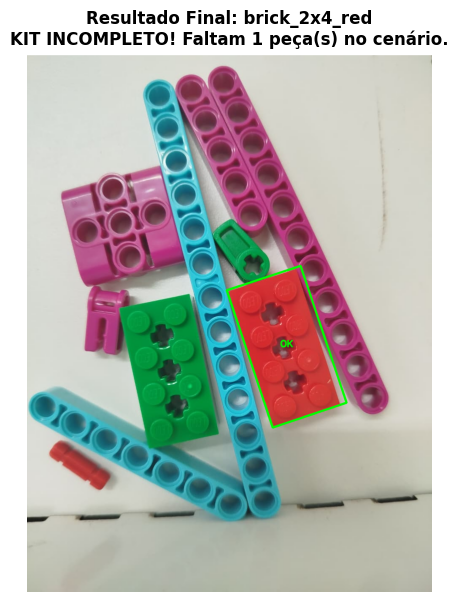

In [15]:
# ==============================================================================
# ETAPA 5: VALIDAÇÃO DO KIT E EXIBIÇÃO DO RESULTADO VISUAL FINAL
# ==============================================================================
# [TÓPICO PDI: EXIBIÇÃO, ROTULAÇÃO E INTERPRETAÇÃO DE RESULTADOS COM VISÃO COMPUTACIONAL]
# Esta célula realiza a validação lógica entre o total computado espacialmente
# e o gabarito do manual, projetando as caixas delimitadoras sobre a imagem colorida.
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Criamos uma cópia limpa da imagem original para projeção do feedback visual
img_resultado = img_original.copy()

# [TÓPICO PDI: DETECÇÃO DE OBJETOS - ANOTAÇÃO E ROTULAÇÃO]
# Iteração sobre o contorno vencedor da Etapa 4 para realizar a marcação gráfica
for cnt in contornos_validos:
    # Obtemos o retângulo de área mínima rotacionado calculado anteriormente
    rect = cv2.minAreaRect(cnt)
    (cx, cy), (w, h), angle = rect

    # [TÓPICO PDI: TRANSFORMAÇÕES GEOMÉTRICAS - MAPEAMENTO DE VÉRTICES]
    # Converte os parâmetros do retângulo rotacionado em 4 pontos de coordenadas (X, Y)
    box = cv2.boxPoints(rect)

   # Usamos np.int64 para indexação de pixels
    box = np.int64(box)

    # Desenha o contorno retangular rotacionado exato ao redor do LEGO (Cor Verde BGR = 0, 255, 0)
    cv2.drawContours(img_resultado, [box], 0, (0, 255, 0), 3)

    # Insere o texto "OK" posicionado no baricentro/centro geométrico aproximado da peça
    cv2.putText(img_resultado, "OK", (int(cx) - 15, int(cy)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

# Cálculo matemático da discrepância do inventário (Variação de estoque do Kit)
faltam = quantidade_alvo - contagem_pecas

# Geração do relatório em console estruturado para auditoria acadêmica
print("=" * 65)
print("             RELATÓRIO DE CONFERÊNCIA DO KIT LEGO             ")
print("=" * 65)
print(f" Peça analisada: {peca_selecionada}")
print(f" Quantidade na mesa: {contagem_pecas} unidade(s) | Manual pede: {quantidade_alvo} unidade(s)")
print("-" * 65)

# Árvore de decisão lógica para validação do Kit baseado na diferença aritmética
if faltam == 0:
    status_kit = "KIT COMPLETO para este modelo!"
elif faltam > 0:
    status_kit = f"KIT INCOMPLETO! Faltam {faltam} peça(s) no cenário."
else:
    status_kit = f"Há {abs(faltam)} peça(s) SOBRANDO na bancada!"

print(status_kit)
print("=" * 65)

# [TÓPICO PDI: EXIBIÇÃO DO PRODUTO DO PROCESSAMENTO]
# Renderização da imagem final rotulada convertida para o espectro de exibição do Matplotlib (RGB)
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
plt.title(f"Resultado Final: {peca_selecionada}\n{status_kit}", fontsize=12, weight='bold', backgroundcolor='white')
plt.axis('off')
plt.show()